# Phase 5 · 01 — Seeing a model degrade before the chargebacks arrive

**Question.** A fraud label exists only once the cardholder disputes the charge and the chargeback lands — weeks to months after the transaction. Legitimate transactions are never confirmed; they are assumed good once the dispute window closes. So the most recent months, the ones that matter most, have almost no labels. Can we still tell when a model has got worse?

**Setup.** Both models were approved on 2018 (the reference period, fully labelled) and then served through 2019 (the analysis period). Their per-transaction scores already exist (`reports/scores_xgb_*.npz`, `reports/metrics_replay*.npz`); nothing is re-scored here. We know the answer from hindsight — XGBoost degrades, GraphSAGE barely does — which is what makes this a fair test.

**Three views of each month**

| view | needs | available |
|---|---|---|
| realized, hindsight | every label | never, in production |
| realized, labels known so far | labels that have arrived | ~3 months after the month closes |
| **estimated (NannyML CBPE)** | scores only | the day the month closes |

CBPE calibrates the scores on the labelled reference period, then reads *expected* performance off each new month's score distribution. It sees covariate shift (the scores move). It is blind, by construction, to concept drift — scores that keep their shape but change their meaning.

All logic lives in `src/fraud/monitoring/`; this notebook only calls it, so production runs the same code. Kernel: `fraud-monitoring` (`.venv-monitoring` — NannyML conflicts with the main env; see `pyproject.toml`).

In [1]:
import os, warnings
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from fraud.config import load_params, repo_path
from fraud.monitoring import estimate as E, labels as L, sink

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(15); pl.Config.set_tbl_cols(12); pl.Config.set_fmt_str_lengths(40)

params = load_params()
cfg = params["monitoring"]
# FRAUD_NOTEBOOK_SAMPLE=1 runs on a small sample: the smoke test uses it so the
# notebook cannot rot. The committed outputs are a full run.
SAMPLE = 60_000 if os.getenv("FRAUD_NOTEBOOK_SAMPLE") else None
print("mode:", "SAMPLE" if SAMPLE else "FULL", "| reference", cfg["reference_year"], "| analysis", cfg["analysis_years"])

mode: FULL | reference 2018 | analysis [2019]


## 1 · The labels we will not have

Each transaction gets a label-arrival time: a fraud after a lognormal chargeback delay (median 45 days, clipped to 7–120), a legitimate one when its 90-day dispute window closes (`params.yaml: monitoring.labels`). The curve below is what a team actually sees for **January 2019**: how much of the month is labelled, day by day after it closes.

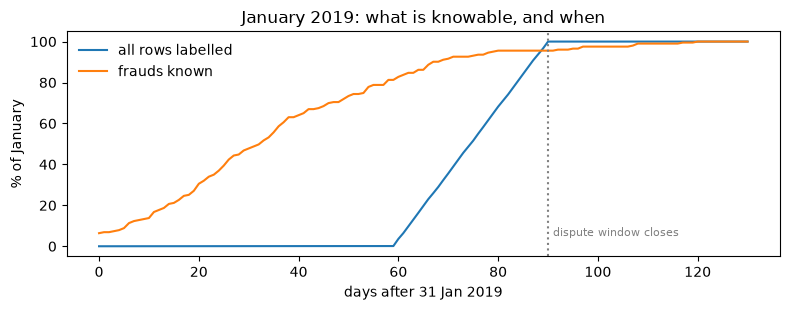

In [2]:
def load(model):
    ref = E.scored_frame(params, model, "reference", sample=SAMPLE)
    ana = L.label_arrival(E.scored_frame(params, model, "analysis", sample=SAMPLE), cfg["labels"])
    return ref, ana

ref_x, ana_x = load("xgboost")
jan = ana_x.filter(pl.col("ts").dt.month() == 1)
month_end = jan["ts"].max()
days = np.arange(0, 131)
coverage = [(jan["labeled_at"] <= month_end + np.timedelta64(int(d), "D")).mean() for d in days]
frauds_known = [jan.filter(pl.col("label") == 1)["labeled_at"].le(month_end + np.timedelta64(int(d), "D")).mean() for d in days]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(days, np.array(coverage) * 100, label="all rows labelled")
ax.plot(days, np.array(frauds_known) * 100, label="frauds known")
ax.axvline(90, ls=":", c="grey"); ax.text(91, 5, "dispute window closes", fontsize=8, color="grey")
ax.set_xlabel("days after 31 Jan 2019"); ax.set_ylabel("% of January"); ax.legend(frameon=False)
ax.set_title("January 2019: what is knowable, and when"); plt.tight_layout(); plt.show()

Frauds surface first; legitimate rows only when their window closes. A metric computed on the labels known at day 30 is not a noisy version of the real one — it is computed on a subset that is mostly fraud, so it is *biased*, not just uncertain. A month becomes trustworthy only when ~99% of it is labelled (`min_label_coverage`), about **90 days after it ends**.

## 2 · XGBoost: the three views, month by month

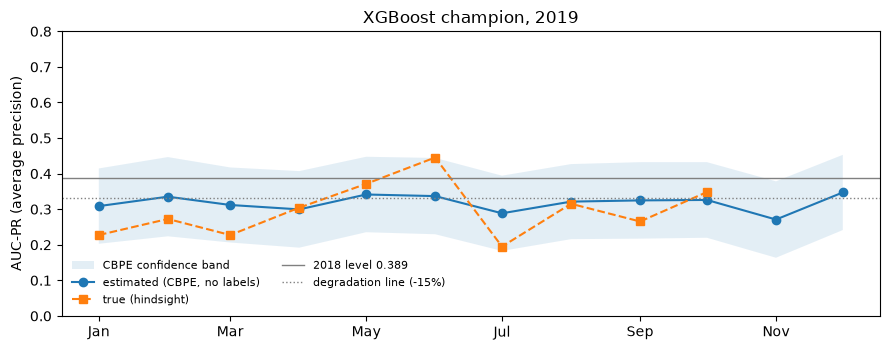

chunk_start,estimated,true,frauds,relative_change,degraded,nannyml_alert,days_after_month_end
datetime[μs],f64,f64,i64,f64,bool,bool,f64
2019-01-01 00:00:00,0.308727,0.22746,203,-0.205547,true,false,89.645833
2019-02-01 00:00:00,0.335204,0.272595,156,-0.137412,false,false,89.660417
2019-03-01 00:00:00,0.311898,0.227419,215,-0.197386,true,false,89.64375
2019-04-01 00:00:00,0.299518,0.304385,218,-0.229243,true,false,89.651389
2019-05-01 00:00:00,0.341373,0.371225,260,-0.121537,false,false,89.65
2019-06-01 00:00:00,0.336859,0.445347,215,-0.133154,false,false,89.654861
2019-07-01 00:00:00,0.288532,0.195064,156,-0.257515,true,false,89.646528
2019-08-01 00:00:00,0.32135,0.31526,247,-0.173062,true,false,89.645833
2019-09-01 00:00:00,0.324772,0.265522,142,-0.164258,true,false,89.652083


In [3]:
def views(model, ref, ana):
    est = E.estimate_performance(ref, ana, params)
    ap = est.filter(pl.col("metric") == "estimated_average_precision")
    ref_level = E.realized_performance(ref, params).filter(
        pl.col("metric") == "realized_average_precision")["value"].mean()
    ap = E.flag_degradation(ap, ref_level, cfg["degradation_tolerance"])
    truth = E.realized_performance(ana, params).filter(pl.col("metric") == "realized_average_precision")
    ready = E.first_label_based_view(ana, params)
    table = (ap.select("chunk_start", "chunk_end", pl.col("value").alias("estimated"),
                       "lower_bound", "upper_bound", "relative_change", "degraded",
                       pl.col("alert").alias("nannyml_alert"))
             .join(truth.select("chunk_start", pl.col("value").alias("true"),
                                pl.col("positives_known").alias("frauds")), on="chunk_start")
             .join(ready.select("chunk_start", "labels_ready_at", "days_after_month_end"), on="chunk_start"))
    return {"model": model, "estimates": est, "ref_level": ref_level, "table": table}

def chart(v, title):
    t = v["table"].sort("chunk_start"); x = t["chunk_start"].to_numpy()
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.fill_between(x, t["lower_bound"], t["upper_bound"], alpha=0.12, label="CBPE confidence band")
    ax.plot(x, t["estimated"], marker="o", label="estimated (CBPE, no labels)")
    ax.plot(x, t["true"], marker="s", ls="--", label="true (hindsight)")
    ax.axhline(v["ref_level"], c="grey", lw=1, label=f"2018 level {v['ref_level']:.3f}")
    ax.axhline(v["ref_level"] * (1 - cfg["degradation_tolerance"]), c="grey", lw=1, ls=":",
               label=f"degradation line (-{cfg['degradation_tolerance']:.0%})")
    ax.set_ylim(0, 0.8); ax.set_ylabel("AUC-PR (average precision)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8, ncol=2, loc="lower left"); plt.tight_layout(); plt.show()

vx = views("xgboost", ref_x, ana_x)
chart(vx, "XGBoost champion, 2019")
vx["table"].select("chunk_start", "estimated", "true", "frauds", "relative_change", "degraded",
                   "nannyml_alert", "days_after_month_end")

## 3 · GraphSAGE: same code, different model

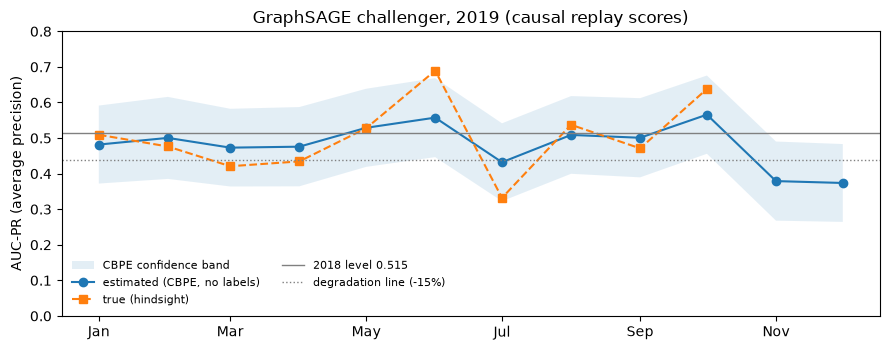

chunk_start,estimated,true,frauds,relative_change,degraded,nannyml_alert,days_after_month_end
datetime[μs],f64,f64,i64,f64,bool,bool,f64
2019-01-01 00:00:00,0.481727,0.509232,203,-0.064052,false,false,89.645833
2019-02-01 00:00:00,0.500451,0.476301,156,-0.027673,false,false,89.660417
2019-03-01 00:00:00,0.473078,0.420822,215,-0.080856,false,false,89.64375
2019-04-01 00:00:00,0.475751,0.434394,218,-0.075663,false,false,89.651389
2019-05-01 00:00:00,0.528803,0.527571,260,0.027412,false,false,89.65
2019-06-01 00:00:00,0.557439,0.689434,215,0.083049,false,false,89.654861
2019-07-01 00:00:00,0.43206,0.331919,156,-0.16055,true,false,89.646528
2019-08-01 00:00:00,0.508788,0.537364,247,-0.011474,false,false,89.645833
2019-09-01 00:00:00,0.500857,0.471062,142,-0.026883,false,false,89.652083


In [4]:
ref_g, ana_g = load("graphsage")
vg = views("graphsage", ref_g, ana_g)
chart(vg, "GraphSAGE challenger, 2019 (causal replay scores)")
vg["table"].select("chunk_start", "estimated", "true", "frauds", "relative_change", "degraded",
                   "nannyml_alert", "days_after_month_end")

## 4 · Did the estimate see it, and how much sooner?

For each model: the 2018 level, the true and estimated 2019 level (Jan–Oct, the months with fraud), and the first month each method would have raised a flag. CBPE can flag a month the day it closes; a label-based check has to wait until that month's labels are complete.

In [5]:
def lead(v):
    t = v["table"].filter(pl.col("true").is_not_nan()).sort("chunk_start")
    tol = cfg["degradation_tolerance"]
    est_flag = t.filter(pl.col("degraded"))
    lab_flag = t.filter(pl.col("true") < (1 - tol) * v["ref_level"])
    first_est = est_flag["chunk_end"].min() if est_flag.height else None
    first_lab = lab_flag["labels_ready_at"].min() if lab_flag.height else None
    return {
        "model": v["model"],
        "reference_2018": round(v["ref_level"], 4),
        "true_2019": round(t["true"].mean(), 4),
        "estimated_2019": round(t["estimated"].mean(), 4),
        "true_change": f"{t['true'].mean() / v['ref_level'] - 1:+.0%}",
        "estimated_change": f"{t['estimated'].mean() / v['ref_level'] - 1:+.0%}",
        "monthly_mae": round((t["estimated"] - t["true"]).abs().mean(), 4),
        "cbpe_flags_on": first_est.date() if first_est else None,
        "labels_flag_on": first_lab.date() if first_lab else None,
        "lead_days": (first_lab - first_est).days if first_est and first_lab else None,
        "months_flagged_cbpe": f"{int(t['degraded'].sum())}/{t.height}",
        "months_below_line_true": f"{lab_flag.height}/{t.height}",
        "nannyml_alerts": int(t["nannyml_alert"].sum()),
    }

summary = pl.DataFrame([lead(vx), lead(vg)])
summary

model,reference_2018,true_2019,estimated_2019,true_change,estimated_change,…,cbpe_flags_on,labels_flag_on,lead_days,months_flagged_cbpe,months_below_line_true,nannyml_alerts
str,f64,f64,f64,str,str,…,date,date,i64,str,str,i64
"""xgboost""",0.3886,0.2972,0.3194,"""-24%""","""-18%""",…,2019-01-31,2019-05-01,89,"""7/10""","""7/10""",0
"""graphsage""",0.5147,0.5036,0.5025,"""-2%""","""-2%""",…,2019-07-31,2019-06-29,-33,"""1/10""","""3/10""",0


## 5 · The blind spot: a month with no fraud

TabFormer has **no fraud at all after October 2019**. Nothing in the scores says so — fraud stopping is a change in the *label* distribution, not in the inputs — so CBPE keeps estimating as if fraud were still arriving at the reference rate. Realized AUC-PR is undefined for those months; the estimate is not.

In [6]:
pl.concat([
    v["table"].filter(pl.col("chunk_start").dt.month() >= 10)
     .select(pl.lit(v["model"]).alias("model"), "chunk_start", "estimated", "true", "frauds")
    for v in (vx, vg)
])

model,chunk_start,estimated,true,frauds
str,datetime[μs],f64,f64,i64
"""xgboost""",2019-10-01 00:00:00,0.326047,0.348194,275
"""xgboost""",2019-11-01 00:00:00,0.270983,NaN,0
"""xgboost""",2019-12-01 00:00:00,0.347132,NaN,0
"""graphsage""",2019-10-01 00:00:00,0.565792,0.638006,275
"""graphsage""",2019-11-01 00:00:00,0.379047,NaN,0
"""graphsage""",2019-12-01 00:00:00,0.373753,NaN,0


## 6 · Input drift

Jensen-Shannon distance between each month and 2018, per input, plus the score itself. Drift explains *why* an estimate moved; it is not itself a performance metric — an input can drift harmlessly, and a model can degrade with no input drift at all (concept drift).

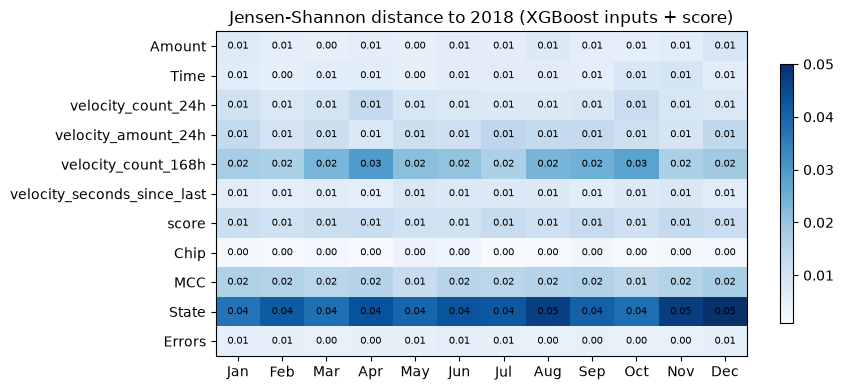

features alerting in any month: ['Amount', 'State', 'Time', 'velocity_seconds_since_last']


In [7]:
drift_x = E.univariate_drift(ref_x, ana_x, params)
heat = (drift_x.with_columns(pl.col("chunk_start").dt.strftime("%b").alias("month"))
        .pivot(on="month", index="feature", values="value", aggregate_function="first"))
months = [c for c in heat.columns if c != "feature"]
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(heat.select(months).to_numpy(), aspect="auto", cmap="Blues")
ax.set_xticks(range(len(months)), months); ax.set_yticks(range(heat.height), heat["feature"].to_list())
for (i, j), val in np.ndenumerate(heat.select(months).to_numpy()):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Jensen-Shannon distance to 2018 (XGBoost inputs + score)"); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
print("features alerting in any month:", sorted(drift_x.filter("alert")["feature"].unique().to_list()))

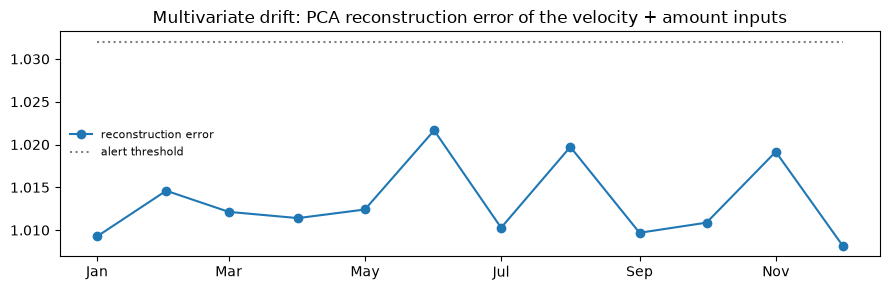

In [8]:
recon = E.multivariate_drift(ref_x, ana_x, params)
fig, ax = plt.subplots(figsize=(9, 3))
x = recon["chunk_start"].to_numpy()
ax.plot(x, recon["value"], marker="o", label="reconstruction error")
ax.plot(x, recon["upper_threshold"], ls=":", c="grey", label="alert threshold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.legend(frameon=False, fontsize=8)
ax.set_title("Multivariate drift: PCA reconstruction error of the velocity + amount inputs")
plt.tight_layout(); plt.show()

## 7 · Store it the way production will

Every estimate and drift value becomes a `drift_metrics` row (`sink.drift_rows`), tagged with its model. They are written to Parquet here; set `FRAUD_WRITE_SUPABASE=1` to also append them to the live table (`sql/004_monitoring.sql` adds the `model` column). Labels are *not* bulk-written: a year of them is most of the 500 MB free tier, and in production they arrive incrementally anyway.

In [9]:
rows = pl.concat([
    sink.drift_rows(vx["estimates"], "xgboost"),
    sink.drift_rows(vg["estimates"], "graphsage"),
    sink.drift_rows(drift_x, "xgboost"),
    sink.drift_rows(recon, "xgboost"),
])
target = repo_path(params["monitoring"]["output_dir"])   # works from any working directory
target.mkdir(parents=True, exist_ok=True)
if not SAMPLE:
    rows.write_parquet(f"{target}/drift_metrics.parquet")
    summary.write_csv(f"{target}/detection_summary.csv")
print(rows.height, "drift_metrics rows;", rows.group_by("model", "metric").len().sort("model", "metric").rows())

if os.getenv("FRAUD_WRITE_SUPABASE") and not SAMPLE:
    from fraud.api import store
    with store.connect() as conn:
        written = sink.write_drift_metrics(conn, rows)
        conn.commit()
    print("written to Supabase:", written)

192 drift_metrics rows; [('graphsage', 'estimated_average_precision', 12), ('graphsage', 'estimated_roc_auc', 12), ('xgboost', 'estimated_average_precision', 12), ('xgboost', 'estimated_roc_auc', 12), ('xgboost', 'jensen_shannon', 132), ('xgboost', 'reconstruction_error', 12)]


## Reading the results (full run, 3 Oct 2026)

**XGBoost's degradation is visible the day the first month closes.** Its 2018 monthly level is 0.389; the true 2019 level is 0.297 (−24%), and CBPE — with no labels — puts it at 0.319 (−18%). CBPE flags it on **31 Jan 2019**; the earliest a label-based check could have confirmed it is **1 May 2019**, when January's labels were complete. That is **89 days** sooner, and the degradation is persistent: most months sit below the line under both views.

**GraphSAGE is correctly read as stable.** True −2%, estimated −2%. The flags it does raise are single months (CBPE: July, which really was weak at 0.332; labels: March). With ~200 frauds a month, one month's AUC-PR swings by ±0.1 on noise alone, so a production rule should require a persistent drop (e.g. two consecutive months, or quarterly chunks) before paging anyone. The count of flagged months separates the two models far better than the first flag does.

**NannyML's own alerts never fired** for either model. Its band is ±3σ of the reference *months*, and monthly AUC-PR noise makes that band so wide (XGBoost's lower threshold is 0) that a real 24% drop sits inside it. The relative-drop rule (`degradation_tolerance`) is what makes the estimate actionable.

**The estimate cannot see fraud stop.** November–December 2019 contain zero frauds, yet CBPE keeps estimating 0.27–0.38: a change in the *label* distribution leaves the scores untouched. Label-free estimation covers covariate shift; prior and concept shift still need labels, and the delayed-label pipeline is what eventually catches them.

**Inputs drifted** on `Amount`, `State`, `Time` and `velocity_seconds_since_last`. That explains part of why XGBoost's scores moved; it does not by itself say performance fell — that is what the estimate is for.

**For production:** run `estimate_performance` + `flag_degradation` on each closed month, write `drift_metrics` (with `model`), and treat a persistent flag on the champion as the trigger the rollback path in Phase 6 listens to.